# Run jaxions 2D cylindrical simulations

The program works with very few options, it is likely to segfault if you run it with others. 

The options are specified in the caxion23loops.py functions

caxion3d only works with GPU (other propagators are standard 2D without cylindrical boundaries)

Boundary conditions far from the strings are not properly implemented so make sure you only measure quantities where boundary effects are causally disconnected. 

output data are moved to folder /data/out... make sure you create the /data directory!

some data for ICs is saved in /aux, make sure you have it too!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyaxions import jaxions as pa

import caxion23loops

# Preparations 

In [14]:
# create data dirs
!mkdir data
!mkdir aux

mkdir: cannot create directory ‘data’: File exists
mkdir: cannot create directory ‘aux’: File exists


In [13]:
# build an interpolation function to speed up ICs
caxion23loops.buildf1f2(ninterp=10000)

tableszetat1t2_4.pkl  saved


(array([0.00000000e+00, 1.00010001e-04, 2.00020002e-04, ...,
        9.99799980e-01, 9.99899990e-01, 1.00000000e+00], shape=(10000,)),
 array([1.        , 1.        , 1.        , ..., 0.99949277, 0.99972045,
        1.        ], shape=(10000,)),
 array([1.        , 1.        , 1.        , ..., 1.00018032, 1.00009882,
        1.        ], shape=(10000,)))

In [9]:
help(caxion23loops.simu)

Help on function simu in module caxion23loops:

simu(R, msa, N, Ng=2, plota=False, rescale=1, n_save=200)
    simu(R,msa,N,Ng=2,plota=False,rescale=1,n_save=200)
    Prepares files for a NxN caxion3d simulation and runs then.
    ICs are prepared in python as a static loop of radious R
    where theta is calcualted from KR equivalent B-field
    and rho according to the distance from the string and msa
    dx = 1, msa = equivalent to saxion mass
    The program currently works only in Minkowsky, FRW is easy to implement
    Ng is the number of neighbours in the laplacian
    n_save is hoe many measurements are desired before collapse (approx(
    rescale does not work always, keep it to 1
    plota gives some extra info



# Run

In [15]:
# run a simulation in the GPU with 256
caxion23loops.simu(R=128.5,msa=0.5,N=256,Ng=2,plota=True,n_save=200)

Simulation
Creation with N,R,msa =  256 128.5 0.5
ICs not found we will create them
Copy into file 256 128.5 0.5
saving jaxions file (256, 256, 2)
Run jaxions 256 128.5 0.5


# Read

data is saved according to N,msa and Ng (different values of R would take the same name so watch out!)

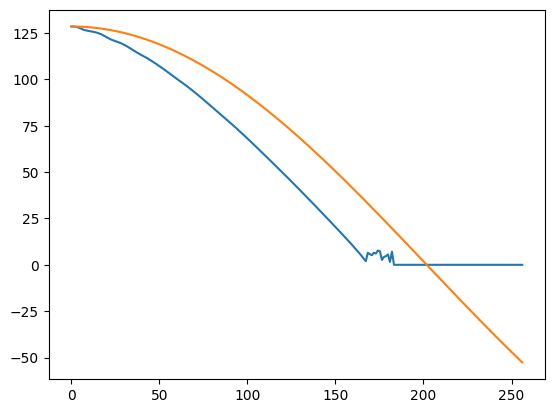

In [16]:
# list measurement files
mf = pa.findmfiles('data/out256-500-2/')
# build the radius as a function of t and estimate of gamma
t,r,g = caxion23loops.buildr(mf)
plt.plot(t,r)
plt.plot(t,r[1]*np.cos(t/r[1]))

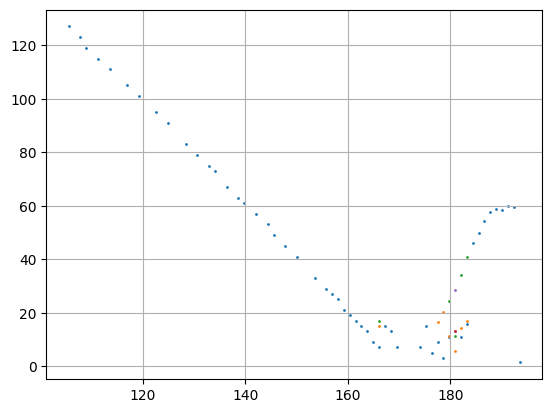

In [18]:
# coordinates of any string are saved with dx = 0.5 precision 
# since main string is at z=0 at the border of a plaquette they fail very often during the normal collapse
# there are also tagget strings, which are not physical, at the boundaries, one needs to disregard those
# note that after collapse, many strings appear, not only the expected bounce
for i in range(len(mf)):
    co = pa.gm(mf[i],'da//string/codata/data')
    ct = pa.gm(mf[i],'ct')
    N  = pa.gm(mf[0],'N')
    if len(co)>0:
        co = np.reshape(co,(len(co)//3,3))
        mask = (co[:,0] < N//2+2)&(co[:,1]<N//2)
        # plt.scatter(co[mask,0],co[mask,1])
        cp = np.linalg.norm(co[mask],axis=1)
        for j in range(len(co[mask])):
            plt.scatter(ct,cp[j],c='C%d'%j,s=1)
        
plt.grid()